In [1]:
import pandas as pd 
df = pd.read_csv('talentwell_data.csv')
df.head(10)

,horas_trabajo_dia,modalidad,horas_sueno,reuniones_dia,anios_experiencia,actividad_fisica_semanal,score_agotamiento,riesgo_burnout
0,9.5,remoto,7.1,4,13.6,0,4.80,0
1,8.2,hibrido,4.8,3,11.6,0,5.30,0
2,9.8,presencial,6.9,2,1.6,0,5.19,1
3,11.5,remoto,4.0,3,3.4,3,7.97,1
4,8.0,remoto,7.3,4,9.6,1,4.79,0
5,8.0,remoto,7.6,5,0.0,4,5.11,0
6,11.7,hibrido,5.8,4,6.7,5,4.20,0
7,10.0,presencial,6.6,5,11.9,5,4.97,0
8,7.6,hibrido,8.8,4,0.4,5,3.42,0
9,9.6,presencial,5.9,4,0.7,1,4.84,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Herramientas listas.")

Herramientas listas.


In [3]:
df = pd.read_csv('talentwell_data.csv')
print(f"Dataset: {df.shape[0]} colaboradores, {df.shape[1]} variables\n")

# Revisión de tipos y nulos
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())
print("\n=== Vista general del target: score_agotamiento ===")
print(df['score_agotamiento'].describe().round(2))

Dataset: 1500 colaboradores, 8 variables

=== Tipos de datos ===
horas_trabajo_dia           float64
modalidad                       str
horas_sueno                 float64
reuniones_dia                 int64
anios_experiencia           float64
actividad_fisica_semanal      int64
score_agotamiento           float64
riesgo_burnout                int64
dtype: object

=== Valores nulos por columna ===
horas_trabajo_dia           0
modalidad                   0
horas_sueno                 0
reuniones_dia               0
anios_experiencia           0
actividad_fisica_semanal    0
score_agotamiento           0
riesgo_burnout              0
dtype: int64

=== Vista general del target: score_agotamiento ===
count    1500.00
mean        4.98
std         1.61
min         0.00
25%         3.84
50%         5.02
75%         6.08
max        10.00
Name: score_agotamiento, dtype: float64


In [4]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
modalidad_encoded = ohe.fit_transform(df[['modalidad']])

# Obtener los nombres de las columnas nuevas
nombres_columnas = ohe.get_feature_names_out(['modalidad']).tolist()
print("Columnas creadas por OHE:", nombres_columnas)

# Agregar las columnas al DataFrame
for i, col in enumerate(nombres_columnas):
    df[col] = modalidad_encoded[:, i]

# Verificar el resultado
print("\nEjemplos de encoding:")
print(df[['modalidad'] + nombres_columnas].drop_duplicates().sort_values('modalidad'))

Columnas creadas por OHE: ['modalidad_presencial', 'modalidad_remoto']

Ejemplos de encoding:
    modalidad  modalidad_presencial  modalidad_remoto
1     hibrido                   0.0               0.0
2  presencial                   1.0               0.0
0      remoto                   0.0               1.0


In [5]:
features = [
    'horas_trabajo_dia',
    'horas_sueno',
    'reuniones_dia',
    'actividad_fisica_semanal',
    'anios_experiencia',
    'modalidad_presencial',   
    'modalidad_remoto'        
]

X = df[features]                     
y = df['score_agotamiento']           

print(f"X (features):  {X.shape}  → {X.shape[0]} registros, {X.shape[1]} variables de entrada")
print(f"y (target):    {y.shape}  → {y.shape[0]} valores a predecir")
print(f"\nRango del target: {y.min():.2f} – {y.max():.2f}")
print(f"Media del target: {y.mean():.2f}")

X (features):  (1500, 7)  → 1500 registros, 7 variables de entrada
y (target):    (1500,)  → 1500 valores a predecir

Rango del target: 0.00 – 10.00
Media del target: 4.98


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba (300 registros)
    random_state=42     
)

print(f"Entrenamiento: {X_train.shape[0]} registros — el modelo va a ver ESTOS datos")
print(f"Prueba:        {X_test.shape[0]} registros — el modelo NUNCA va a ver estos durante el entrenamiento")

Entrenamiento: 1200 registros — el modelo va a ver ESTOS datos
Prueba:        300 registros — el modelo NUNCA va a ver estos durante el entrenamiento


In [10]:
modelo_lineal = LinearRegression()

modelo_lineal.fit(X_train, y_train)

print("Modelo entrenado.")
print(f"\nIntercepto (β₀): {modelo_lineal.intercept_:.4f}")
print("→ El modelo 'arranca' en este valor antes de sumar el efecto de cada variable.")
print("→ El valor de negocio real está en los coeficientes — celda siguiente.")

Modelo entrenado.

Intercepto (β₀): 3.1091
→ El modelo 'arranca' en este valor antes de sumar el efecto de cada variable.
→ El valor de negocio real está en los coeficientes — celda siguiente.


In [11]:
coeficientes = pd.DataFrame({
    'feature':     features,
    'coeficiente': modelo_lineal.coef_
}).sort_values('coeficiente', ascending=False)

print("=== Lo que aprendió el modelo ===")
print(coeficientes.to_string(index=False))

=== Lo que aprendió el modelo ===
                 feature  coeficiente
       horas_trabajo_dia     0.472838
        modalidad_remoto     0.380606
           reuniones_dia     0.354788
       anios_experiencia     0.005304
actividad_fisica_semanal    -0.232357
    modalidad_presencial    -0.360631
             horas_sueno    -0.484095


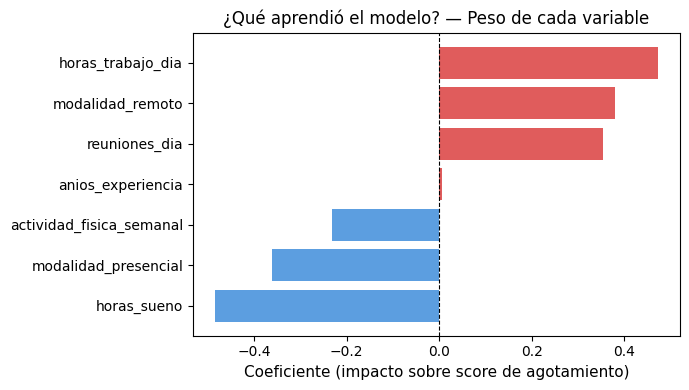

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#e05c5c' if c > 0 else '#5c9ee0' for c in coeficientes['coeficiente']]
ax.barh(coeficientes['feature'], coeficientes['coeficiente'], color=colores)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (impacto sobre score de agotamiento)', fontsize=11)
ax.set_title('¿Qué aprendió el modelo? — Peso de cada variable', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
y_pred = modelo_lineal.predict(X_test)

print(f"Predicciones generadas: {len(y_pred)}")
print(f"Primeras 5 predicciones: {y_pred[:5].round(2)}")
print(f"Primeros 5 valores reales: {y_test.values[:5].round(2)}")
print("\n¿Se parecen? La distancia entre cada par es el error del modelo en ese caso.")

Predicciones generadas: 300
Primeras 5 predicciones: [7.07 5.33 4.24 5.25 4.38]
Primeros 5 valores reales: [7.1  4.72 5.31 4.81 3.29]

¿Se parecen? La distancia entre cada par es el error del modelo en ese caso.


In [14]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Desempeño del modelo sobre datos nuevos ===\n")
print(f"R²   {r2:.4f}  → explica el {r2*100:.1f}% de la variación en el agotamiento")
print(f"MAE  {mae:.4f}  → error promedio de ±{mae:.2f} puntos sobre escala 0–10")
print(f"RMSE {rmse:.4f}  → error penalizando casos donde el modelo falla más")
print()
print(f"El {(1-r2)*100:.1f}% restante depende de factores fuera del dataset.")
print(f"Si alguien tiene score real 6.2, el modelo predijo entre {6.2-mae:.2f} y {6.2+mae:.2f}.")

=== Desempeño del modelo sobre datos nuevos ===

R²   0.7061  → explica el 70.6% de la variación en el agotamiento
MAE  0.6859  → error promedio de ±0.69 puntos sobre escala 0–10
RMSE 0.8584  → error penalizando casos donde el modelo falla más

El 29.4% restante depende de factores fuera del dataset.
Si alguien tiene score real 6.2, el modelo predijo entre 5.51 y 6.89.


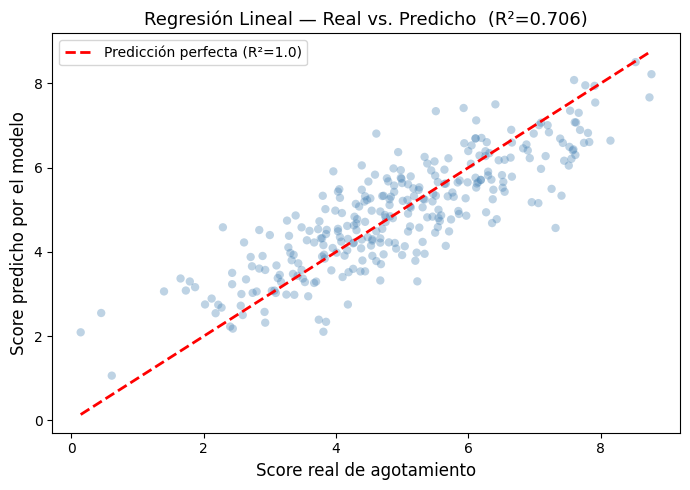

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.35, color='steelblue', edgecolors='none')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label=f'Predicción perfecta (R²=1.0)'
)
plt.xlabel('Score real de agotamiento', fontsize=12)
plt.ylabel('Score predicho por el modelo', fontsize=12)
plt.title(f'Regresión Lineal — Real vs. Predicho  (R²={r2:.3f})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()